In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mri-dataset/MRI Dataset/Kaggle MRI Alzheimers
/kaggle/input/mri-dataset/MRI Dataset/train.parquet
/kaggle/input/mri-dataset/MRI Dataset/test.parquet


In [2]:
# ===============================
# Imports & Environment Setup
# ===============================

# Core numerical and data handling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os

# Deep learning (PyTorch)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# -------------------------------
# Reproducibility
# -------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# -------------------------------
# Device configuration
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Setup complete. Using device:", device)


Setup complete. Using device: cuda


In [3]:
# ===============================
# Load MRI Dataset (Parquet Format)
# ===============================

# Define file paths for the official training and testing splits
# The dataset is stored in Parquet format for efficient loading
TRAIN_PATH = "/kaggle/input/mri-dataset/MRI Dataset/train.parquet"
TEST_PATH  = "/kaggle/input/mri-dataset/MRI Dataset/test.parquet"

# Load the Parquet files into pandas DataFrames
# Each row represents one MRI sample with:
#  - 'image': Brain MRI stored as a NumPy array
#  - 'label': Integer class label (e.g., Normal, MCI, Alzheimer’s)
train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

# Display dataset sizes to verify successful loading
print(f"Training samples: {train_df.shape}")
print(f"Test samples: {test_df.shape}")

# Preview the dataset structure to confirm schema and data integrity
train_df.head()


Training samples: (5120, 2)
Test samples: (1280, 2)


,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,2
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,2


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

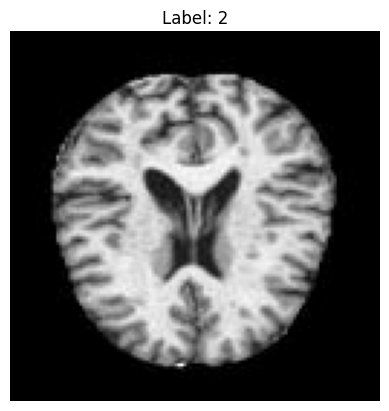

In [4]:
# ===============================
# Minimal EDA: MRI Image Visualization
# ===============================

from PIL import Image
from io import BytesIO

# Select a single sample from the training dataset
# This step is used to visually verify that MRI images are decoded correctly
sample = train_df.iloc[0]

# Extract raw image bytes and the corresponding class label
image_bytes = sample["image"]["bytes"]
label = sample["label"]

# Decode the image bytes and convert to grayscale
# MRI scans are single-channel images, so grayscale is sufficient
image = Image.open(BytesIO(image_bytes)).convert("L")

# Display the MRI image
plt.imshow(image, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")


In [5]:
# ===============================
# Custom PyTorch Dataset for MRI Data
# ===============================

class AlzheimerMRIDataset(Dataset):
    """
    Custom PyTorch Dataset for loading Alzheimer’s MRI scans stored in Parquet files.

    For each sample, this dataset:
    - Decodes MRI image data from raw bytes
    - Converts the image to grayscale (single-channel MRI)
    - Applies optional preprocessing and data augmentation
    - Returns the processed image tensor along with its class label
    """

    def __init__(self, dataframe, transform=None):
        # Store the DataFrame and reset index for safe indexing
        self.df = dataframe.reset_index(drop=True)

        # Optional torchvision transforms (resize, normalization, augmentation, etc.)
        self.transform = transform

    def __len__(self):
        # Return total number of samples in the dataset
        return len(self.df)

    def __getitem__(self, idx):
        # Retrieve one sample by index
        sample = self.df.iloc[idx]

        # Decode MRI image bytes stored in the parquet file
        image_bytes = sample["image"]["bytes"]
        image = Image.open(BytesIO(image_bytes)).convert("L")

        # Extract and cast the class label
        label = int(sample["label"])

        # Apply preprocessing / augmentation if specified
        if self.transform:
            image = self.transform(image)

        # Return image-label pair for model training or evaluation
        return image, label


In [6]:
# ===============================
# Image Transformations & Preprocessing
# ===============================

# Standard input resolution required by ResNet architectures
IMAGE_SIZE = 224

# -------------------------------
# Training Transformations
# -------------------------------
# These transformations prepare MRI images for model training and
# introduce mild data augmentation to improve generalization.
train_transform = transforms.Compose([
    # Resize all images to a fixed size expected by the ResNet model
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Random horizontal flip to reduce overfitting
    # (applied conservatively to preserve anatomical consistency)
    transforms.RandomHorizontalFlip(p=0.5),

    # Convert PIL image to PyTorch tensor
    transforms.ToTensor(),

    # Normalize image using ImageNet statistics adapted for single-channel MRI
    # This ensures stable and faster model convergence
    transforms.Normalize(mean=[0.485], std=[0.229])
])

# -------------------------------
# Validation / Test Transformations
# -------------------------------
# Only deterministic preprocessing is applied during evaluation
# to ensure consistent and fair performance measurement.
val_transform = transforms.Compose([
    # Resize to match model input size
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Convert image to tensor
    transforms.ToTensor(),

    # Apply the same normalization used during training
    transforms.Normalize(mean=[0.485], std=[0.229])
])


In [7]:
# ===============================
# Train–Validation Split
# ===============================

from sklearn.model_selection import train_test_split

# Split the original training dataset into training and validation subsets
# The validation set is used to monitor generalization performance
# and to detect potential overfitting during training.
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,              # Reserve 20% of data for validation
    random_state=SEED,          # Ensure reproducibility of the split
    stratify=train_df["label"]  # Preserve class distribution across splits
)

# Display dataset sizes to verify successful splitting
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")


Training samples: 4096
Validation samples: 1024


In [8]:
# ===============================
# Dataset & DataLoader Setup
# ===============================

# Number of samples processed in each training iteration
BATCH_SIZE = 32

# -------------------------------
# Dataset Initialization
# -------------------------------
# Create dataset objects by wrapping the DataFrames with the custom
# PyTorch Dataset class and applying the appropriate transformations
train_dataset = AlzheimerMRIDataset(train_df, transform=train_transform)
val_dataset   = AlzheimerMRIDataset(val_df, transform=val_transform)

# -------------------------------
# DataLoader Configuration
# -------------------------------
# DataLoaders handle batching, shuffling, and parallel data loading
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,              # Shuffle training data for better generalization
    num_workers=2,             # Enable parallel data loading
    pin_memory=True            # Improve GPU transfer efficiency
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,             # No shuffling during validation
    num_workers=2,
    pin_memory=True
)

# Confirm successful DataLoader initialization
print("Training and validation DataLoaders are ready.")


Training and validation DataLoaders are ready.


In [9]:
# ===============================
# Training Function (Single Epoch)
# ===============================

def train_one_epoch(model, loader, criterion, optimizer):
    """
    Train the model for one complete epoch.

    Args:
        model (nn.Module): Neural network model
        loader (DataLoader): DataLoader providing training batches
        criterion (nn.Module): Loss function
        optimizer (Optimizer): Optimization algorithm

    Returns:
        avg_loss (float): Average training loss over the epoch
        accuracy (float): Training accuracy for the epoch
    """

    # Set model to training mode (enables dropout, batch norm, etc.)
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Iterate over training batches
    for images, labels in loader:
        # Move data to GPU if available
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass: compute model predictions
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass: compute gradients
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate loss for reporting
        running_loss += loss.item()

        # Compute batch predictions for accuracy calculation
        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    # Compute average loss and accuracy for the epoch
    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy


In [10]:
# ===============================
# Model, Loss, and Optimizer Setup
# ===============================

from torchvision import models

# Determine the number of output classes from the dataset
num_classes = train_df["label"].nunique()

# -------------------------------
# Model Initialization
# -------------------------------
# Load a ResNet18 model pretrained on ImageNet
# Pretraining helps the model learn robust low-level features
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify the first convolution layer to accept single-channel (grayscale) MRI images
# This adapts the ImageNet-trained model for medical imaging input
model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# Replace the final fully connected layer to match the number of target classes
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move the model to the selected device (GPU if available)
model = model.to(device)

# -------------------------------
# Loss Function
# -------------------------------
# Cross-entropy loss with label smoothing
# Label smoothing improves generalization and reduces overconfidence
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# -------------------------------
# Optimizer
# -------------------------------
# Adam optimizer is used for stable and efficient training
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Confirm successful model initialization
print("ResNet18 model initialized on:", device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


ResNet18 model initialized on: cuda


In [11]:
# ===============================
# Model Evaluation Function
# ===============================

def evaluate(model, loader, criterion):
    """
    Evaluate the trained model on validation or test data.

    Args:
        model (nn.Module): Trained PyTorch model
        loader (DataLoader): DataLoader for validation or test dataset
        criterion (nn.Module): Loss function

    Returns:
        avg_loss (float): Average loss over the dataset
        accuracy (float): Classification accuracy
        all_preds (list): Predicted class indices
        all_labels (list): Ground truth class labels
    """

    # Set model to evaluation mode (disables dropout, uses running stats in batch norm)
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # Store predictions and labels for detailed analysis (e.g., confusion matrix)
    all_preds = []
    all_labels = []

    # Disable gradient computation for faster and memory-efficient inference
    with torch.no_grad():
        for images, labels in loader:
            # Move data to GPU if available
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass (inference)
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Accumulate loss
            running_loss += loss.item()

            # Get predicted class labels
            _, predicted = torch.max(outputs, dim=1)

            # Update accuracy counters
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            # Store predictions and labels on CPU for post-analysis
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute average loss and overall accuracy
    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy, all_preds, all_labels


In [12]:
# ===============================
# Training Loop
# ===============================

# Number of training epochs
EPOCHS = 5

# Track the best validation accuracy for model checkpointing
best_val_acc = 0.0

# Iterate over training epochs
for epoch in range(EPOCHS):

    # -------------------------------
    # Training Phase
    # -------------------------------
    # Train the model for one full epoch on the training dataset
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer
    )

    # -------------------------------
    # Validation Phase
    # -------------------------------
    # Evaluate model performance on the validation dataset
    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion
    )

    # -------------------------------
    # Model Checkpointing
    # -------------------------------
    # Save the model weights if validation accuracy improves
    # This ensures the best-performing model is preserved
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet.pth")

    # -------------------------------
    # Progress Logging
    # -------------------------------
    # Print training and validation metrics for the current epoch
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

# Final training summary
print("Training complete. Best validation accuracy:", best_val_acc)


Epoch [1/5] Train Loss: 0.9362, Train Acc: 0.6128 | Val Loss: 0.7991, Val Acc: 0.6826
Epoch [2/5] Train Loss: 0.6617, Train Acc: 0.7737 | Val Loss: 0.6259, Val Acc: 0.7822
Epoch [3/5] Train Loss: 0.4530, Train Acc: 0.8918 | Val Loss: 0.5171, Val Acc: 0.8535
Epoch [4/5] Train Loss: 0.3488, Train Acc: 0.9409 | Val Loss: 0.6464, Val Acc: 0.8135
Epoch [5/5] Train Loss: 0.3019, Train Acc: 0.9673 | Val Loss: 0.4082, Val Acc: 0.9004
Training complete. Best validation accuracy: 0.900390625


In [13]:
# ===============================
# Grad-CAM Implementation
# ===============================

class GradCAM:
    """
    Gradient-weighted Class Activation Mapping (Grad-CAM) for CNN models.

    This class generates class-specific heatmaps that highlight
    the image regions most influential for a given prediction,
    enabling interpretability of deep learning models.
    """

    def __init__(self, model, target_layer):
        # Store the trained model and the target convolutional layer
        self.model = model
        self.target_layer = target_layer

        # Variables to store forward activations and backward gradients
        self.gradients = None
        self.activations = None

        # Register forward and backward hooks on the target layer
        self._register_hooks()

    def _register_hooks(self):
        """
        Register hooks to capture:
        - Forward activations from the target convolutional layer
        - Backward gradients during backpropagation
        """

        # Hook to capture feature maps during forward pass
        def forward_hook(module, input, output):
            self.activations = output

        # Hook to capture gradients during backward pass
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        # Attach hooks to the target layer
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx):
        """
        Generate a Grad-CAM heatmap for a given input image and target class.

        Args:
            input_tensor (Tensor): Input image tensor (1 x C x H x W)
            class_idx (int): Target class index

        Returns:
            cam (ndarray): Normalized Grad-CAM heatmap
        """

        # Set model to evaluation mode
        self.model.eval()

        # Clear existing gradients
        self.model.zero_grad()

        # Forward pass to obtain model predictions
        output = self.model(input_tensor)

        # Select the score corresponding to the target class
        score = output[:, class_idx]

        # Backward pass to compute gradients w.r.t. target layer
        score.backward()

        # Compute channel-wise importance weights using global average pooling
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        # Weighted combination of feature maps
        cam = (weights * self.activations).sum(dim=1)

        # Apply ReLU to retain only positive contributions
        cam = torch.relu(cam)

        # Convert heatmap to NumPy format for visualization
        cam = cam.squeeze().detach().cpu().numpy()

        # Normalize heatmap for stable visualization
        if cam.max() != 0:
            cam = cam / cam.max()

        return cam


In [14]:
# ===============================
# Grad-CAM Initialization
# ===============================

# Initialize Grad-CAM using the trained ResNet model
# The final convolutional block (layer4) is selected because:
# - It contains high-level semantic features
# - It preserves sufficient spatial resolution
# - It provides the most class-discriminative information
grad_cam = GradCAM(
    model=model,
    target_layer=model.layer4
)


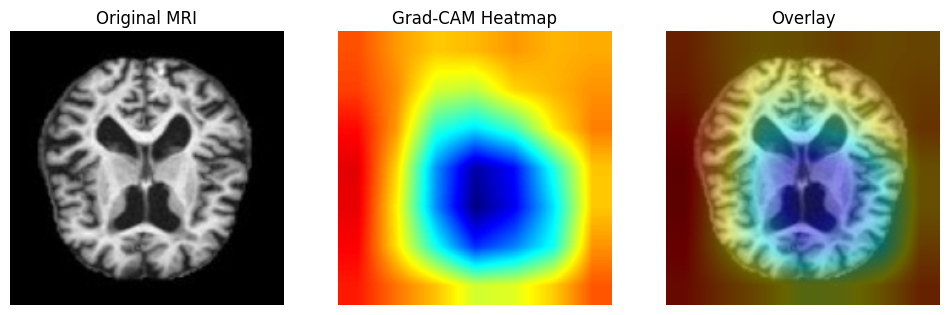

True Label: 2
Predicted Label: 2


In [15]:
# ===============================
# Grad-CAM Visualization
# ===============================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Load Best Model Checkpoint
# -------------------------------
# Load the best-performing model weights saved during training
# This ensures Grad-CAM explanations correspond to the optimal model
model.load_state_dict(torch.load("best_resnet.pth", map_location=device))
model.eval()

# -------------------------------
# Select a Validation Sample
# -------------------------------
# Retrieve one sample from the validation dataset for visualization
sample_img, sample_label = val_dataset[0]

# Add batch dimension and move input to device
input_tensor = sample_img.unsqueeze(0).to(device)

# -------------------------------
# Model Prediction
# -------------------------------
# Perform a forward pass to obtain the predicted class
with torch.no_grad():
    output = model(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()

# -------------------------------
# Generate Grad-CAM Heatmap
# -------------------------------
# Compute the class-specific Grad-CAM activation map
cam = grad_cam.generate(input_tensor, pred_class)

# -------------------------------
# Image & Heatmap Preparation
# -------------------------------
# Convert the grayscale MRI image to NumPy format and normalize
img_np = sample_img.squeeze().cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

# Resize Grad-CAM map to match original image resolution
cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

# Apply a color map to the Grad-CAM heatmap for better visualization
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap = heatmap.astype(np.float32) / 255.0

# Convert grayscale MRI to 3-channel format for overlay visualization
img_rgb = np.stack([img_np] * 3, axis=-1)

# Overlay the heatmap on the original MRI image
overlay = 0.6 * img_rgb + 0.4 * heatmap

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original MRI")
plt.imshow(img_np, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()

# Display true and predicted labels for reference
print("True Label:", sample_label)
print("Predicted Label:", pred_class)


In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import io
from PIL import Image

os.makedirs("gradcam_outputs", exist_ok=True)

def generate_and_save_gradcam(
    model, grad_cam, dataset, idx, save_name
):
    model.eval()
    
    img, true_label = dataset[idx]
    input_tensor = img.unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        output = model(input_tensor)
        pred_label = torch.argmax(output, dim=1).item()

    # Grad-CAM
    cam = grad_cam.generate(input_tensor, pred_label)

    # Prepare image
    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET
    )
    heatmap = heatmap / 255.0

    overlay = np.clip(0.6 * img_np + 0.4 * heatmap, 0, 1)

    # Plot
    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.title("Original MRI")
    plt.imshow(img_np)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Grad-CAM")
    plt.imshow(heatmap)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    plt.suptitle(
        f"True: {true_label} | Pred: {pred_label}",
        fontsize=12
    )

    save_path = f"gradcam_outputs/{save_name}.png"
    plt.savefig(save_path, bbox_inches="tight")
    plt.close()

    print(f"Saved:", save_path)
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import io
from PIL import Image

# Create output directory to store Grad-CAM visualizations
os.makedirs("gradcam_outputs", exist_ok=True)

def generate_and_save_gradcam(
    model, grad_cam, dataset, idx, save_name
):
    """
    Generate and save Grad-CAM visualization for a given dataset sample.

    Args:
        model (nn.Module): Trained classification model
        grad_cam (GradCAM): Initialized Grad-CAM object
        dataset (Dataset): Validation or test dataset
        idx (int): Index of the sample to visualize
        save_name (str): Filename for saving the output image
    """

    # Set model to evaluation mode
    model.eval()
    
    # Retrieve image and true label from the dataset
    img, true_label = dataset[idx]

    # Add batch dimension and move input to device
    input_tensor = img.unsqueeze(0).to(device)

    # -------------------------------
    # Model Prediction
    # -------------------------------
    # Perform forward pass to obtain predicted class
    with torch.no_grad():
        output = model(input_tensor)
        pred_label = torch.argmax(output, dim=1).item()

    # -------------------------------
    # Grad-CAM Generation
    # -------------------------------
    # Generate class-specific Grad-CAM heatmap
    cam = grad_cam.generate(input_tensor, pred_label)

    # -------------------------------
    # Image & Heatmap Preparation
    # -------------------------------
    # Convert tensor image to NumPy format and normalize
    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    # Resize Grad-CAM map to match image resolution
    cam_resized = cv2.resize(cam, (224, 224))

    # Apply color mapping for better visual contrast
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET
    )
    heatmap = heatmap / 255.0

    # Overlay heatmap on original MRI image
    overlay = np.clip(0.6 * img_np + 0.4 * heatmap, 0, 1)

    # -------------------------------
    # Visualization & Saving
    # -------------------------------
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original MRI")
    plt.imshow(img_np)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Grad-CAM")
    plt.imshow(heatmap)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    # Display true and predicted labels for reference
    plt.suptitle(
        f"True: {true_label} | Pred: {pred_label}",
        fontsize=12
    )

    # Save visualization to disk
    save_path = f"gradcam_outputs/{save_name}.png"
    plt.savefig(save_path, bbox_inches="tight")
    plt.close()

    print(f"Saved:", save_path)


In [17]:
# ===============================
# Collect Correct Predictions per Class
# ===============================

from collections import defaultdict

# Dictionary to store indices of correctly classified samples for each class
# This helps in selecting representative examples for qualitative analysis
correct_indices = defaultdict(list)

# Set model to evaluation mode
model.eval()

# Disable gradient computation for efficient inference
with torch.no_grad():
    # Iterate over the validation dataset
    for idx in range(len(val_dataset)):
        # Retrieve image and true label
        img, label = val_dataset[idx]

        # Prepare input tensor
        input_tensor = img.unsqueeze(0).to(device)

        # Forward pass to obtain prediction
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()

        # Store indices of correctly predicted samples
        # Limit to a small number per class for concise visualization
        if pred == label and len(correct_indices[label]) < 2:
            correct_indices[label].append(idx)

# Convert defaultdict to a standard dictionary for cleaner display
correct_indices = dict(correct_indices)

# Display selected correct sample indices per class
correct_indices


{2: [0, 1], 3: [3, 4], 0: [5, 8], 1: [49, 99]}

In [18]:
# ===============================
# Generate & Save Grad-CAM Examples
# ===============================

# Counter to limit the total number of saved Grad-CAM visualizations
count = 0

# Iterate over correctly predicted samples grouped by class
for label, indices in correct_indices.items():
    for idx in indices:
        # Generate and save Grad-CAM visualization for the selected sample
        generate_and_save_gradcam(
            model,
            grad_cam,
            val_dataset,
            idx,
            save_name=f"class_{label}_example_{count}"
        )

        # Increment saved sample counter
        count += 1

        # Stop once the desired number of examples is reached
        if count >= 5:
            break

    # Exit outer loop as well once limit is reached
    if count >= 5:
        break


Saved: gradcam_outputs/class_2_example_0.png
Saved: gradcam_outputs/class_2_example_1.png
Saved: gradcam_outputs/class_3_example_2.png
Saved: gradcam_outputs/class_3_example_3.png
Saved: gradcam_outputs/class_0_example_4.png


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.87      0.91       145
           1       1.00      0.80      0.89        10
           2       0.87      0.97      0.92       513
           3       0.93      0.81      0.87       356

    accuracy                           0.90      1024
   macro avg       0.94      0.86      0.90      1024
weighted avg       0.90      0.90      0.90      1024



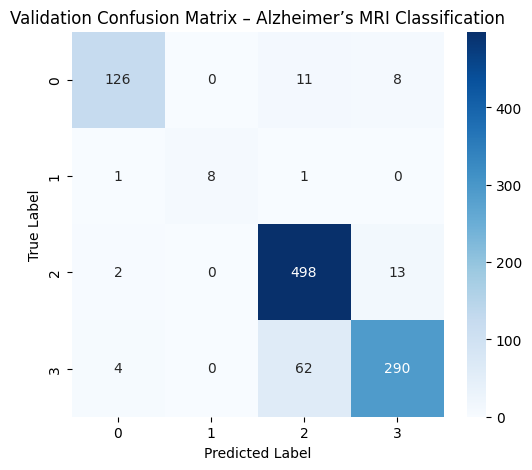

In [30]:
# ===============================
# Confusion Matrix & Classification Report
# ===============================

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Lists to store predictions and ground-truth labels
all_preds = []
all_labels = []

# Set model to evaluation mode
model.eval()

# Disable gradient computation for efficient inference
with torch.no_grad():
    # Iterate over the validation dataset
    for images, labels in val_loader:
        # Move data to device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass to obtain model predictions
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        # Store predictions and true labels for metric computation
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# -------------------------------
# Classification Report
# -------------------------------
# Displays precision, recall, and F1-score for each class
# Useful for analyzing class-wise performance beyond accuracy
print("Classification Report:\n")
print(classification_report(all_labels, all_preds))

# -------------------------------
# Confusion Matrix
# -------------------------------
# Compute confusion matrix to visualize prediction errors
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Validation Confusion Matrix – Alzheimer’s MRI Classification")
plt.show()


In [20]:
# ===============================
# Load Test Dataset
# ===============================

# Load the held-out test dataset from parquet format
# The test set is used only for final performance evaluation
# and is never seen during training or validation
test_df = pd.read_parquet(
    "/kaggle/input/mri-dataset/MRI Dataset/test.parquet"
)

# Display the size of the test dataset to verify successful loading
print("Test samples:", test_df.shape)


Test samples: (1280, 2)


In [21]:
# ===============================
# Test Dataset & DataLoader Setup
# ===============================

# Create the test dataset using the same preprocessing pipeline
# as validation data to ensure consistent evaluation
test_dataset = AlzheimerMRIDataset(
    test_df, transform=val_transform
)

# Initialize DataLoader for the test dataset
# Shuffling is disabled to preserve sample order during evaluation
test_loader = DataLoader(
    test_dataset,
    batch_size=32,          # Batch size for inference
    shuffle=False,          # No shuffling during testing
    num_workers=2,          # Parallel data loading
    pin_memory=True         # Faster data transfer to GPU
)

# Confirm successful test DataLoader initialization
print("Test DataLoader ready.")


Test DataLoader ready.


In [22]:
# ===============================
# Test Set Evaluation
# ===============================

# Lists to store model predictions and ground-truth labels from the test set
test_preds = []
test_labels = []

# Set model to evaluation mode
model.eval()

# Disable gradient computation for efficient and memory-safe inference
with torch.no_grad():
    # Iterate over the test dataset
    for images, labels in test_loader:
        # Move data to the selected device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass to obtain model outputs
        outputs = model(images)

        # Select the predicted class with the highest score
        preds = torch.argmax(outputs, dim=1)

        # Store predictions and true labels for metric computation
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Confirm completion of test inference
print("Test predictions collected.")


Test predictions collected.


In [23]:
# ===============================
# Test Set Accuracy
# ===============================

test_acc = accuracy_score(test_labels, test_preds)
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9000


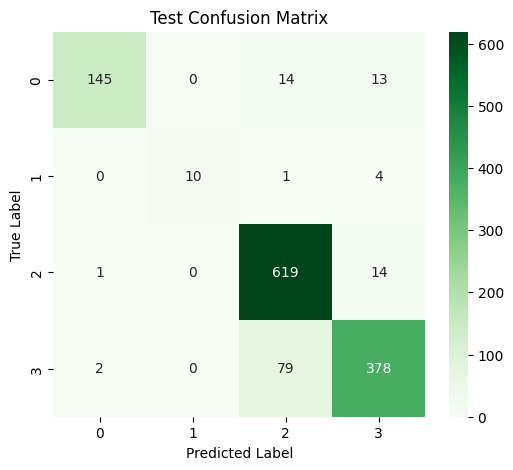

In [24]:
# ===============================
# Test Confusion Matrix
# ===============================

# Compute the confusion matrix using test set predictions
cm_test = confusion_matrix(test_labels, test_preds)

# Plot the confusion matrix as a heatmap for clear visualization
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Greens"   # Distinct color map to differentiate test results
)

# Label axes and add title for clarity
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Save the confusion matrix for submission and reporting
plt.savefig("test_confusion_matrix.png", bbox_inches="tight")
plt.show()


In [25]:
# ===============================
# Final Test Evaluation
# ===============================

# Load best model checkpoint
model.load_state_dict(torch.load("best_resnet.pth", map_location=device))
model.eval()

test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Test accuracy
test_acc = accuracy_score(test_labels, test_preds)
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9000


In [26]:
# ===============================
# Final Test Evaluation
# ===============================

# Load the best-performing model checkpoint saved during training
# This ensures the final evaluation uses the optimal model
model.load_state_dict(torch.load("best_resnet.pth", map_location=device))
model.eval()

# Lists to store predictions and ground-truth labels from the test set
test_preds = []
test_labels = []

# Disable gradient computation for efficient inference
with torch.no_grad():
    # Iterate over the test DataLoader
    for images, labels in test_loader:
        # Move inputs and labels to the selected device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass to obtain model outputs
        outputs = model(images)

        # Select the predicted class with the highest confidence
        preds = torch.argmax(outputs, dim=1)

        # Store predictions and true labels for metric computation
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Compute overall accuracy on the held-out test set
test_acc = accuracy_score(test_labels, test_preds)
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9000


In [27]:
import os
os.listdir("/kaggle/working/")


['.virtual_documents',
 'best_resnet.pth',
 'test_confusion_matrix.png',
 'gradcam_outputs']

In [28]:
os.listdir("/kaggle/working/gradcam_outputs")


['class_0_example_4.png',
 'class_2_example_0.png',
 'class_3_example_2.png',
 'class_3_example_3.png',
 'class_2_example_1.png']

In [29]:
import torch
from torchvision import models
import torch.nn as nn

# -------------------------------
# Recreate the Trained Model Architecture
# -------------------------------
# The architecture must EXACTLY match the one used during training
# to correctly load the saved weights
model_check = models.resnet18(weights=None)

# Modify the first convolution layer for single-channel (grayscale) MRI input
# This must match the training-time modification
model_check.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# Replace the final fully connected layer to match the number of classes
model_check.fc = nn.Linear(model_check.fc.in_features, num_classes)

# -------------------------------
# Load Saved Model Weights
# -------------------------------
# Load the best model checkpoint saved during training
# map_location="cpu" ensures compatibility even without GPU
model_check.load_state_dict(
    torch.load("/kaggle/working/best_resnet.pth", map_location="cpu")
)

# Set model to evaluation mode for inference
model_check.eval()

# Confirmation message
print("✅ Model loaded successfully and architecture matches.")


✅ Model loaded successfully and architecture matches.
